Dữ liệu: Comment tiếng Việt (giống bản 3,4).

Tiền xử lý: Như bản 4 (tokenize, teen code, stop words) và thêm: chuyển emoji thành text, giữ lại dấu !?.

Đặc trưng: Kết hợp TF‑IDF (trên text đã xử lý) + đặc trưng số học (độ dài, số !, số ?, số chữ hoa, số emoji) trích từ comment gốc. Dùng hstack để ghép ma trận.

Mô hình: LogisticRegression (không cố định class_weight). GridSearch tìm cả C và class_weight (các giá trị: 'balanced', {0:1,1:1.5}, {0:1,1:2}, {0:1,1:3}, None).

Chia tập: Dựa trên indices để lưu comment gốc hiển thị FP/FN.

Đánh giá: Đầy đủ (ROC, PR, calibration, CV 5‑fold, FP/FN).

Đặc điểm: Tiến bộ nhất: xử lý tiếng Việt + đặc trưng số + emoji + tự động chọn class_weight tối ưu.

In [ ]:
!pip install underthesea emoji

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata
import emoji

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    average_precision_score,
    auc,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

from underthesea import word_tokenize

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = "/content/drive/MyDrive/CommentClassificationDataset/train_full.csv"
data = pd.read_csv(DATA_PATH)

print(data.columns)
print(data.head())
print("\nCount:\n", data["is_violation"].value_counts(dropna=False))
print("\nRatio:\n", data["is_violation"].value_counts(normalize=True, dropna=False))

data["comment"] = data["comment"].astype(str).fillna("")
data["is_violation"] = data["is_violation"].astype(int)

Index(['comment', 'is_violation'], dtype='object')
                                             comment  is_violation
0                                                cặc           1.0
1                   đr hết thời cày rank bk còn ngợp           0.0
2         Diễn viên hô ni hút mà ngại gì mấy khác kk           0.0
3  Toàn bọn vô công rồi nghề ngồi sủa ăn lương th...           1.0
4  lên kim cương bố ỉa vào mồm mày với cái lối lê...           1.0

Count:
 is_violation
1.0    3668
0.0    2684
Name: count, dtype: int64

Ratio:
 is_violation
1.0    0.577456
0.0    0.422544
Name: proportion, dtype: float64


In [ ]:
vietnamese_stopwords = set([
    'và', 'của', 'một', 'những', 'các', 'đã', 'sẽ', 'là', 'có',
    'được', 'cũng', 'nhưng', 'hoặc', 'khi', 'nếu', 'vì', 'rất',
    'quá', 'lắm', 'ơi', 'ạ', 'nhé', 'à', 'ối', 'ôi', 'a', 'b', 'c',
    'mà', 'thì', 'bị', 'do', 'tại', 'theo', 'vào', 'ra', 'lên', 'xuống',
    'này', 'kia', 'ấy', 'đó', 'nơi', 'chỗ', 'việc', 'điều', 'cái', 'con',
    'hơn', 'như', 'cùng', 'để', 'cho', 'về', 'từ', 'trong', 'ngoài', 'trên',
    'dưới', 'giữa', 'với', 'bằng', 'ở', 'tới', 'lại', 'đang', 'rồi', 'thôi'
])

In [ ]:
teen_code_dict = {
    'k': 'không', 'ko': 'không', 'khong': 'không', 'hok': 'không', 'hog': 'không',
    'j': 'gì', 'z': 'vậy', 'vcl': 'vãi cả lồn', 'dm': 'địt mẹ', 'đm': 'địt mẹ',
    'cc': 'cặc', 'cl': 'cặc', 'loz': 'lồn', 'lon': 'lồn', 'cmn': 'cái mẹ',
    'vcc': 'vãi cả cặc', 'vl': 'vãi lồn', 'đỉ': 'địt', 'du ma': 'địt mẹ',
    'wtf': 'what the fuck', 'vs': 'vãi', 'bg': 'bao giờ', 'ntn': 'như thế nào',
    'ntnao': 'như thế nào', 'dc': 'được', 'dk': 'điều kiện', 'wa': 'quá', 'wá': 'quá'
}

def expand_teen_code(text):
    words = text.split()
    expanded = []
    for w in words:
        w_lower = w.lower()
        if w_lower in teen_code_dict:
            expanded.append(teen_code_dict[w_lower])
        else:
            expanded.append(w)
    return ' '.join(expanded)

In [ ]:
def replace_emoji_with_text(text):
    return emoji.demojize(text, delimiters=(" ", " "))

def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in vietnamese_stopwords]
    return ' '.join(words)

def preprocess_vietnamese(text, expand_teen=True, remove_stop=True):
    if not isinstance(text, str):
        text = str(text)
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r'[^\w\s!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = replace_emoji_with_text(text)
    if expand_teen:
        text = expand_teen_code(text)
    tokens = word_tokenize(text)
    text = ' '.join(tokens)
    if remove_stop:
        text = remove_stopwords(text)
    return text

# Áp dụng tiền xử lý
data['comment_processed'] = data['comment'].apply(
    lambda x: preprocess_vietnamese(x, expand_teen=True, remove_stop=True)
)

In [ ]:
def extract_numeric_features(text_series):
    """Trích xuất đặc trưng số từ comment gốc (chưa qua tiền xử lý)"""
    lengths = text_series.str.len().values.reshape(-1, 1)
    num_exclamation = text_series.str.count('!').values.reshape(-1, 1)
    num_question = text_series.str.count('\\?').values.reshape(-1, 1)
    num_upper = text_series.str.count(r'[A-Z]').values.reshape(-1, 1)
    num_emoji = text_series.apply(lambda x: sum(1 for _ in emoji.emoji_list(x))).values.reshape(-1, 1)

    features = np.hstack([lengths, num_exclamation, num_question, num_upper, num_emoji])
    return features.astype(np.float32)

In [ ]:
# TF-IDF cho comment đã xử lý
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r'(?u)\b\w+\b',
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2,
    max_df=0.9
)

X_tfidf = tfidf_vectorizer.fit_transform(data['comment_processed'])

# Đặc trưng số từ comment gốc
X_numeric = extract_numeric_features(data['comment'])

# Chuẩn hóa đặc trưng số
scaler = StandardScaler(with_mean=False)
X_numeric_scaled = scaler.fit_transform(X_numeric)

# Kết hợp
X_combined = hstack([X_tfidf, csr_matrix(X_numeric_scaled)])

print("Shape of combined features:", X_combined.shape)

Shape of combined features: (6352, 10005)


In [ ]:
y = data['is_violation'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X_combined, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape[0])
print("Val  :", X_val.shape[0])
print("Test :", X_test.shape[0])

Train: 4446
Val  : 953
Test : 953


In [ ]:
# Định nghĩa pipeline đơn giản
pipeline = Pipeline([
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    'clf__C': [0.1, 0.2, 0.5, 1.0, 2.0],
    'clf__class_weight': ['balanced', {0: 1, 1: 1.5}, {0: 1, 1: 2}, {0: 1, 1: 3}, None]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("===== BẮT ĐẦU GRID SEARCH =====")
grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)
print("Best CV F1 :", grid_search.best_score_)

model = grid_search.best_estimator_

===== BẮT ĐẦU GRID SEARCH =====
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'clf__C': 2.0, 'clf__class_weight': None}
Best CV F1 : 0.8728217249271809


In [ ]:
def find_best_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    precision = precision[:-1]
    recall = recall[:-1]
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    return {
        "threshold": thresholds[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx],
        "f1": f1_scores[best_idx]
    }

y_val_prob = model.predict_proba(X_val)[:, 1]
threshold_info = find_best_threshold(y_val, y_val_prob)
best_threshold = threshold_info["threshold"]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision: {threshold_info['precision']:.4f}")
print(f"Recall   : {threshold_info['recall']:.4f}")
print(f"F1       : {threshold_info['f1']:.4f}")

Best threshold: 0.4526
Precision: 0.8571
Recall   : 0.9147
F1       : 0.8850


In [ ]:
def evaluate_model(model, X_split, y_true, threshold=0.5, split_name="DATA"):
    y_prob = model.predict_proba(X_split)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    print(f"\n===== {split_name} =====")
    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"PR-AUC  : {pr_auc:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    print(confusion_matrix(y_true, y_pred))
    return y_prob, y_pred

y_train_prob, y_train_pred = evaluate_model(model, X_train, y_train, best_threshold, "TRAIN")
y_val_prob, y_val_pred = evaluate_model(model, X_val, y_val, best_threshold, "VALIDATION")
y_test_prob, y_test_pred = evaluate_model(model, X_test, y_test, best_threshold, "TEST")


===== TRAIN =====
ROC-AUC : 0.9922
PR-AUC  : 0.9938
              precision    recall  f1-score   support

           0     0.9814    0.9010    0.9395      1879
           1     0.9316    0.9875    0.9588      2567

    accuracy                         0.9510      4446
   macro avg     0.9565    0.9443    0.9491      4446
weighted avg     0.9527    0.9510    0.9506      4446

[[1693  186]
 [  32 2535]]

===== VALIDATION =====
ROC-AUC : 0.9340
PR-AUC  : 0.9539
              precision    recall  f1-score   support

           0     0.8712    0.7910    0.8292       402
           1     0.8571    0.9147    0.8850       551

    accuracy                         0.8625       953
   macro avg     0.8642    0.8529    0.8571       953
weighted avg     0.8631    0.8625    0.8615       953

[[318  84]
 [ 47 504]]

===== TEST =====
ROC-AUC : 0.9234
PR-AUC  : 0.9396
              precision    recall  f1-score   support

           0     0.8765    0.7047    0.7813       403
           1     0.8108 

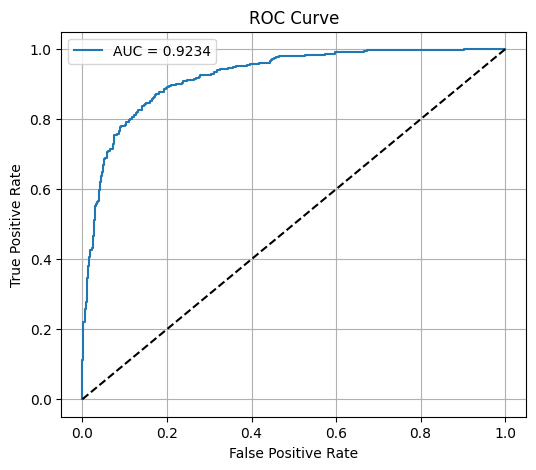

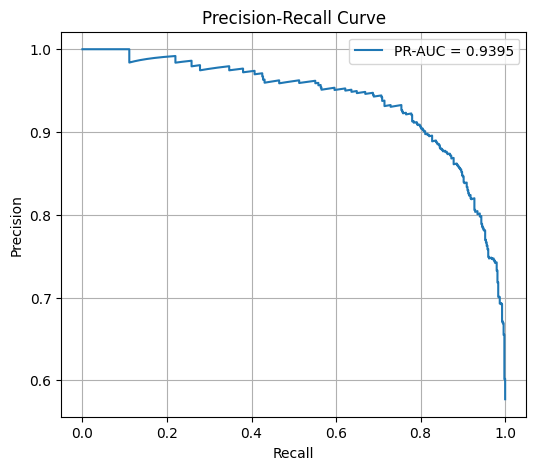

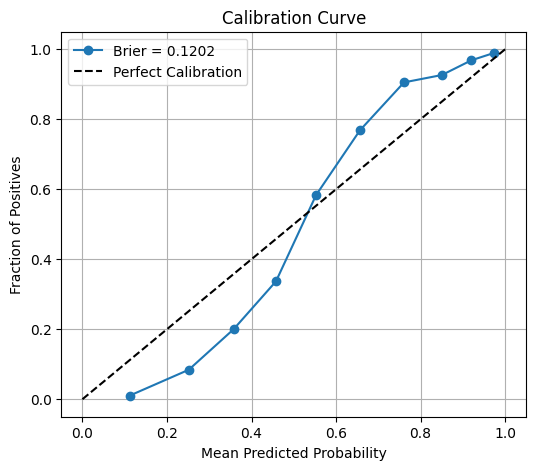

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = auc(recall, precision)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

frac_pos, mean_pred = calibration_curve(y_test, y_test_prob, n_bins=10, strategy='quantile')
brier = brier_score_loss(y_test, y_test_prob)
plt.figure(figsize=(6,5))
plt.plot(mean_pred, frac_pos, marker='o', label=f"Brier = {brier:.4f}")
plt.plot([0,1],[0,1], 'k--', label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
cv_scores = cross_validate(
    model,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    return_train_score=False,
    n_jobs=-1
)

print("\n===== CROSS-VALIDATION (5-fold) =====")
for metric in cv_scores:
    if metric.startswith("test_"):
        vals = cv_scores[metric]
        print(f"{metric}: {vals.mean():.4f} +/- {vals.std():.4f}")


===== CROSS-VALIDATION (5-fold) =====
test_accuracy: 0.8502 +/- 0.0065
test_precision: 0.8560 +/- 0.0077
test_recall: 0.8905 +/- 0.0131
test_f1: 0.8728 +/- 0.0060
test_roc_auc: 0.9281 +/- 0.0053
test_pr_auc: 0.9456 +/- 0.0050


In [ ]:
# Lưu comment gốc trước khi xử lý
original_comments = data['comment'].values

# Tạo DataFrame chứa comment gốc và label
df_full = pd.DataFrame({
    'comment_original': original_comments,
    'label': y
})

# Thực hiện split trên chỉ mục để lấy đúng comment gốc
from sklearn.model_selection import train_test_split

# Lấy chỉ mục của từng tập
indices = np.arange(len(df_full))

# Split indices
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=y, random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y[temp_idx], random_state=42
)

# Lấy comment gốc cho test set
test_comments = df_full.iloc[test_idx]['comment_original'].values
y_test_original = df_full.iloc[test_idx]['label'].values

# Kiểm tra kích thước
print(f"Test set size: {len(test_comments)}")
print(f"y_test shape: {len(y_test_original)}")
print(f"y_test_pred shape: {len(y_test_pred)}")
print(f"y_test_prob shape: {len(y_test_prob)}")

# Hiển thị false positives và false negatives
def show_fp_fn_samples_comments(comments, y_true, y_pred, y_prob, n=10):
    df = pd.DataFrame({
        "comment": comments,
        "true_label": y_true,
        "pred_label": y_pred,
        "prob_violation": y_prob
    })
    fp = df[(df["true_label"] == 0) & (df["pred_label"] == 1)]
    fn = df[(df["true_label"] == 1) & (df["pred_label"] == 0)]

    print(f"\n===== FALSE POSITIVES (Total: {len(fp)}) =====")
    if len(fp) > 0:
        print(fp.sort_values("prob_violation", ascending=False).head(n)[["prob_violation", "comment"]])
    else:
        print("No false positives found!")

    print(f"\n===== FALSE NEGATIVES (Total: {len(fn)}) =====")
    if len(fn) > 0:
        print(fn.sort_values("prob_violation", ascending=True).head(n)[["prob_violation", "comment"]])
    else:
        print("No false negatives found!")

show_fp_fn_samples_comments(test_comments, y_test_original, y_test_pred, y_test_prob, n=10)

Test set size: 953
y_test shape: 953
y_test_pred shape: 953
y_test_prob shape: 953

===== FALSE POSITIVES (Total: 119) =====
     prob_violation                                            comment
93         0.965101  Mai Hà vậy mày coi lại bình luận đầu tiên của ...
310        0.932570  Mày coi lại não mày load hết được cmt tao chưa...
170        0.918352                               Mày nghĩ xl là hết à
860        0.912956              Mấy thằng hàn nó k sang nó vả cho nhỉ
259        0.888289                                        chó bị bệnh
667        0.870669  gì vậy má nó có thật là nó bán cho báo lá cải ...
48         0.856491                Con chó nó ngửi được mùi thằng trộm
882        0.850268         Vcl fb fake mà các bố cmt nhưu thật sợ vcl
739        0.849322  Xin đừng tin ai ở cái xã hội này-lừa đảo , cướ...
592        0.847323  Lê Luân đừng so sánh lương. Mà hãy so sánh quy...

===== FALSE NEGATIVES (Total: 40) =====
     prob_violation                                  